# Analiza szeregów czasowych — Energia elektryczna w Hiszpanii (2015–2018)

Zbiór danych zawiera godzinowe dane o:
- **Produkcji energii** z różnych źródeł (wiatr, słońce, gaz, węgiel, atom...)
- **Zużyciu energii** (rzeczywiste i prognozowane)
- **Cenach energii** (rynek dnia następnego i cena rzeczywista)
- **Pogodzie** w 5 największych miastach Hiszpanii

Źródło danych: [Kaggle – Energy Consumption, Generation, Prices and Weather](https://www.kaggle.com/datasets/nicholasjhana/energy-consumption-generation-prices-and-weather)

---
## 1. Załadowanie danych do DataFrame

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [39]:
energy_df = pd.read_csv(
    "datasets/energy_dataset.csv",
    parse_dates=["time"],
    index_col="time",
)
energy_df.index = pd.to_datetime(energy_df.index, utc=True)

print(f"Kształt:       {energy_df.shape}")
print(f"Zakres dat:    {energy_df.index.min()} → {energy_df.index.max()}")
print(f"Częstotliwość: godzinowa ({len(energy_df):,} godzin ≈ {len(energy_df)/8760:.1f} lat)")
print(f"\nTypy danych:")
print(energy_df.dtypes.value_counts())

Kształt:       (35065, 28)
Zakres dat:    2014-12-31 23:00:00+00:00 → 2018-12-31 23:00:00+00:00
Częstotliwość: godzinowa (35,065 godzin ≈ 4.0 lat)

Typy danych:
float64    28
Name: count, dtype: int64


In [40]:
energy_df.head(3)

,generation biomass,generation fossil brown coal/lignite,generation fossil coal-derived gas,generation fossil gas,generation fossil hard coal,generation fossil oil,generation fossil oil shale,generation fossil peat,generation geothermal,generation hydro pumped storage aggregated,...,generation waste,generation wind offshore,generation wind onshore,forecast solar day ahead,forecast wind offshore eday ahead,forecast wind onshore day ahead,total load forecast,total load actual,price day ahead,price actual
time,,,,,,,,,,,,,,,,,,,,,
2014-12-31 23:00:00+00:00,447.0,329.0,0.0,4844.0,4821.0,162.0,0.0,0.0,0.0,NaN,...,196.0,0.0,6378.0,17.2,NaN,6436.0,26118.0,25385.0,50.10,NaN
2015-01-01 00:00:00+00:00,449.0,328.0,0.0,5196.0,4755.0,158.0,0.0,0.0,0.0,NaN,...,195.0,0.0,5890.0,15.8,NaN,5856.0,24934.0,24382.0,48.10,NaN
2015-01-01 01:00:00+00:00,448.0,323.0,0.0,4857.0,4581.0,157.0,0.0,0.0,0.0,NaN,...,196.0,0.0,5461.0,8.3,NaN,5454.0,23515.0,22734.0,47.33,NaN


In [41]:
weather_df = pd.read_csv(
    "datasets/weather_features.csv",
    parse_dates=["dt_iso"],
    index_col="dt_iso",
)
weather_df.index = pd.to_datetime(weather_df.index, utc=True)

print(f"Kształt:    {weather_df.shape}")
print(f"Miasta:     {weather_df['city_name'].str.strip().unique().tolist()}")
print(f"Zakres dat: {weather_df.index.min()} → {weather_df.index.max()}")

Kształt:    (178396, 16)
Miasta:     ['Valencia', 'Madrid', 'Bilbao', 'Barcelona', 'Seville']
Zakres dat: 2014-12-31 23:00:00+00:00 → 2018-12-31 22:00:00+00:00


---
## 2. Wstępna obróbka danych (pre-processing)

### 2.1 Analiza brakujących wartości

In [42]:
missing = energy_df.isnull().sum()
missing_pct = (missing / len(energy_df) * 100).round(2)

missing_info = pd.DataFrame({"Brakujące": missing, "Procent [%]": missing_pct})
missing_info = missing_info[missing_info["Brakujące"] > 0].sort_values("Brakujące", ascending=False)

print(f"Kolumny z brakującymi wartościami: {len(missing_info)} / {energy_df.shape[1]}")
missing_info

Kolumny z brakującymi wartościami: 27 / 28


,Brakujące,Procent [%]
price actual,35065,100.00
generation hydro pumped storage aggregated,35065,100.00
forecast wind offshore eday ahead,35065,100.00
generation hydro pumped storage consumption,35065,100.00
total load actual,32,0.09
total load forecast,32,0.09
generation marine,19,0.05
generation fossil peat,18,0.05
generation other renewable,18,0.05
generation fossil coal-derived gas,18,0.05


### 2.2 Usunięcie pustych kolumn i uzupełnienie braków

Dwie kolumny mają 100% brakujących wartości — usuwamy je.  
Pozostałe braki (< 0.1%) uzupełniamy metodą **forward fill** — każda luka przyjmuje ostatnią znaną wartość. To standardowe podejście dla szeregów czasowych.

In [43]:
fully_null = [col for col in energy_df.columns if energy_df[col].isnull().all()]
print(f"Kolumny w 100% puste (usuwam): {fully_null}")
energy_df = energy_df.drop(columns=fully_null)

before_na = energy_df.isnull().sum().sum()
energy_df = energy_df.ffill().bfill()
after_na = energy_df.isnull().sum().sum()

print(f"Braki przed uzupełnieniem: {before_na}")
print(f"Braki po uzupełnieniu:     {after_na}")
print(f"\nKształt po czyszczeniu:    {energy_df.shape}")

Kolumny w 100% puste (usuwam): ['generation hydro pumped storage aggregated', 'generation hydro pumped storage consumption', 'forecast wind offshore eday ahead', 'price actual']
Braki przed uzupełnieniem: 409
Braki po uzupełnieniu:     0

Kształt po czyszczeniu:    (35065, 24)


### 2.3 Przygotowanie danych pogodowych

Dane pogodowe zawierają odczyty z 5 miast. Obliczamy średnią krajową dla każdej godziny i konwertujemy temperaturę z Kelwinów na stopnie Celsjusza.

In [44]:
weather_numeric = weather_df.select_dtypes(include=[np.number])
weather_avg = weather_numeric.groupby(weather_numeric.index).mean()

for col in ["temp", "temp_min", "temp_max"]:
    weather_avg[col] = weather_avg[col] - 273.15

weather_avg = weather_avg.rename(columns={
    "temp": "temperatura_sr",
    "temp_min": "temperatura_min",
    "temp_max": "temperatura_max",
    "humidity": "wilgotnosc",
    "wind_speed": "predkosc_wiatru",
    "pressure": "cisnienie",
    "clouds_all": "zachmurzenie",
    "rain_1h": "opady",
})

weather_cols = ["temperatura_sr", "wilgotnosc", "predkosc_wiatru", "cisnienie", "zachmurzenie", "opady"]
weather_avg = weather_avg[weather_cols]

print(f"Średnia pogoda — kształt: {weather_avg.shape}")
print(f"Przykład temperatury: {weather_avg['temperatura_sr'].iloc[0]:.1f}°C")
weather_avg.head()

Średnia pogoda — kształt: (35064, 6)
Przykład temperatury: -0.7°C


,temperatura_sr,wilgotnosc,predkosc_wiatru,cisnienie,zachmurzenie,opady
dt_iso,,,,,,
2014-12-31 23:00:00+00:00,-0.658537,82.4,2.0,1016.4,0.0,0.0
2015-01-01 00:00:00+00:00,-0.637300,82.4,2.0,1016.2,0.0,0.0
2015-01-01 01:00:00+00:00,-1.050862,82.0,2.4,1016.8,0.0,0.0
2015-01-01 02:00:00+00:00,-1.060531,82.0,2.4,1016.6,0.0,0.0
2015-01-01 03:00:00+00:00,-1.004100,82.0,2.4,1016.6,0.0,0.0


### 2.4 Łączenie danych energetycznych z pogodowymi

In [45]:
df = energy_df.join(weather_avg, how="left")
df[weather_cols] = df[weather_cols].ffill().bfill()

print(f"Połączony DataFrame: {df.shape}")
print(f"Braki po połączeniu:  {df.isnull().sum().sum()}")

Połączony DataFrame: (35065, 30)
Braki po połączeniu:  0


### 2.5 Tworzenie nowych zmiennych

In [46]:
generation_cols = [c for c in df.columns if c.startswith("generation")]

renewable_cols = [
    "generation biomass",
    "generation solar",
    "generation wind onshore",
    "generation wind offshore",
    "generation hydro run-of-river and poundage",
    "generation hydro water reservoir",
    "generation other renewable",
]

fossil_cols = [
    "generation fossil gas",
    "generation fossil hard coal",
    "generation fossil brown coal/lignite",
    "generation fossil oil",
    "generation fossil coal-derived gas",
    "generation fossil oil shale",
    "generation fossil peat",
]

df["generacja_oze"] = df[[c for c in renewable_cols if c in df.columns]].sum(axis=1)
df["generacja_paliwa"] = df[[c for c in fossil_cols if c in df.columns]].sum(axis=1)
df["generacja_calkowita"] = df[generation_cols].sum(axis=1)
df["udzial_oze"] = (df["generacja_oze"] / df["generacja_calkowita"] * 100).round(1)

df["godzina"] = df.index.hour
df["dzien_tyg"] = df.index.dayofweek           # 0=poniedziałek, 6=niedziela
df["miesiac"] = df.index.month
df["rok"] = df.index.year
df["weekend"] = df["dzien_tyg"].isin([5, 6]).astype(int)

print("Nowe kolumny:")
new_cols = ["generacja_oze", "generacja_paliwa", "generacja_calkowita", "udzial_oze",
            "godzina", "dzien_tyg", "miesiac", "rok", "weekend"]
df[new_cols].head()

Nowe kolumny:


,generacja_oze,generacja_paliwa,generacja_calkowita,udzial_oze,godzina,dzien_tyg,miesiac,rok,weekend
time,,,,,,,,,
2014-12-31 23:00:00+00:00,9897.0,10156.0,27388.0,36.1,23,2,12,2014,0
2015-01-01 00:00:00+00:00,9127.0,10437.0,26898.0,33.9,0,3,1,2015,0
2015-01-01 01:00:00+00:00,8376.0,9918.0,25632.0,32.7,1,3,1,2015,0
2015-01-01 02:00:00+00:00,7529.0,8859.0,23720.0,31.7,2,3,1,2015,0
2015-01-01 03:00:00+00:00,7152.0,8313.0,22794.0,31.4,3,3,1,2015,0


In [47]:
print(f"\n=== Gotowy DataFrame ===")
print(f"Kształt:        {df.shape}")
print(f"Zakres dat:     {df.index.min()} → {df.index.max()}")
print(f"Braki:          {df.isnull().sum().sum()}")
print(f"Pamięć:         {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")


=== Gotowy DataFrame ===
Kształt:        (35065, 39)
Zakres dat:     2014-12-31 23:00:00+00:00 → 2018-12-31 23:00:00+00:00
Braki:          0
Pamięć:         10.7 MB


---
## 3. Analiza wizualna

### 3.1 Zużycie energii w czasie (4 lata)

Wykres liniowy pokazuje jak zmieniało się zapotrzebowanie na energię godzina po godzinie.  
Widać wyraźny **wzorzec sezonowy** — wyższe zużycie zimą i latem (ogrzewanie/klimatyzacja).

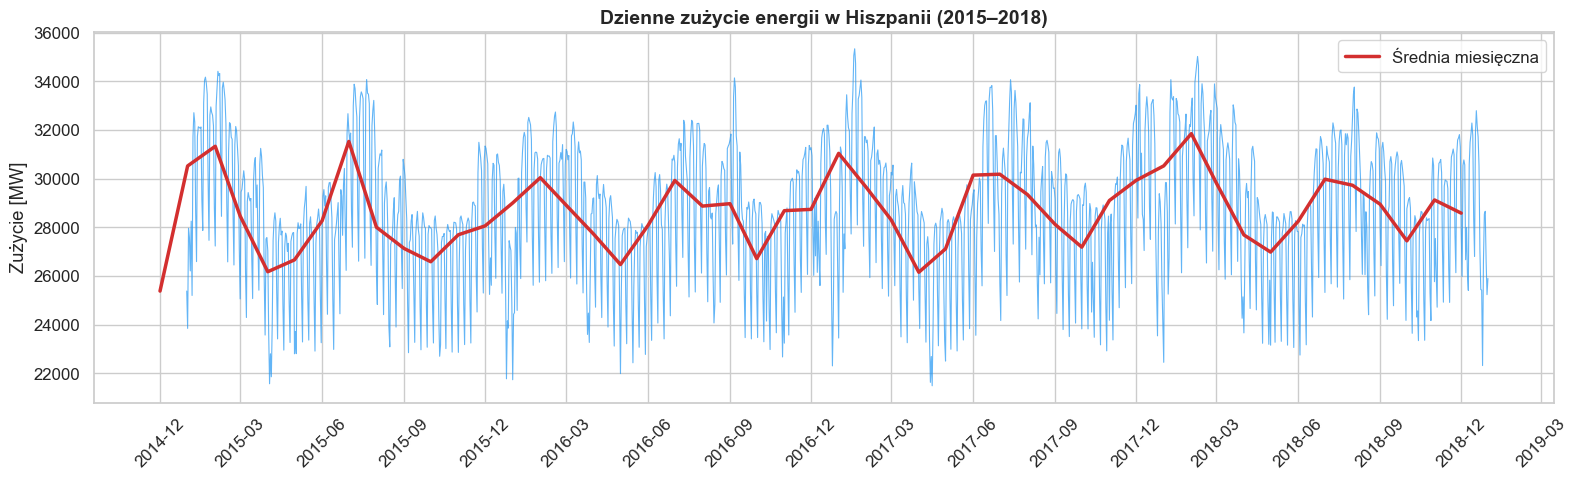

In [48]:
fig, ax = plt.subplots(figsize=(16, 5))

daily_load = df["total load actual"].resample("D").mean()
ax.plot(daily_load.index, daily_load.values, linewidth=0.8, color="#2196F3", alpha=0.7)

monthly_avg = daily_load.resample("MS").mean()
ax.plot(monthly_avg.index, monthly_avg.values, linewidth=2.5, color="#D32F2F", label="Średnia miesięczna")

ax.set_title("Dzienne zużycie energii w Hiszpanii (2015–2018)", fontsize=14, fontweight="bold")
ax.set_ylabel("Zużycie [MW]")
ax.set_xlabel("")
ax.legend()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 3.2 Profil dobowy — dzień roboczy vs. weekend

Jak wygląda typowy dzień pod kątem zużycia energii?  
W dni robocze widać dwa szczyty (rano i wieczorem), w weekendy zużycie jest niższe i bardziej płaskie.

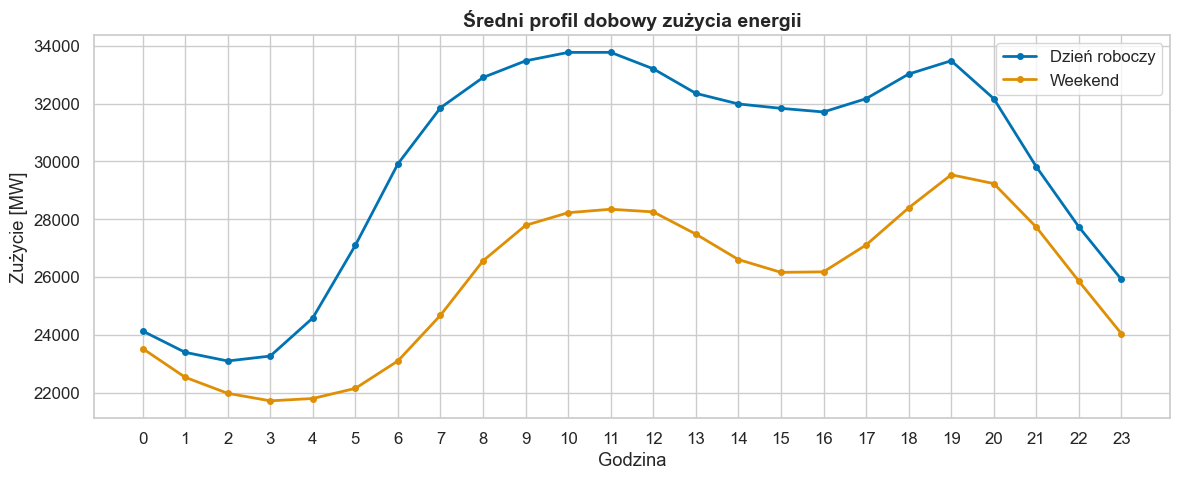

In [49]:
fig, ax = plt.subplots(figsize=(12, 5))

for label, grp in df.groupby("weekend"):
    profile = grp.groupby("godzina")["total load actual"].mean()
    name = "Weekend" if label == 1 else "Dzień roboczy"
    ax.plot(profile.index, profile.values, marker="o", markersize=4, linewidth=2, label=name)

ax.set_title("Średni profil dobowy zużycia energii", fontsize=14, fontweight="bold")
ax.set_xlabel("Godzina")
ax.set_ylabel("Zużycie [MW]")
ax.set_xticks(range(24))
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

### 3.3 Produkcja energii wg źródeł (miesięcznie)

Jak zmienia się miks energetyczny w ciągu roku?  
Latem dominuje energia słoneczna, zimą — wiatrowa i konwencjonalna.

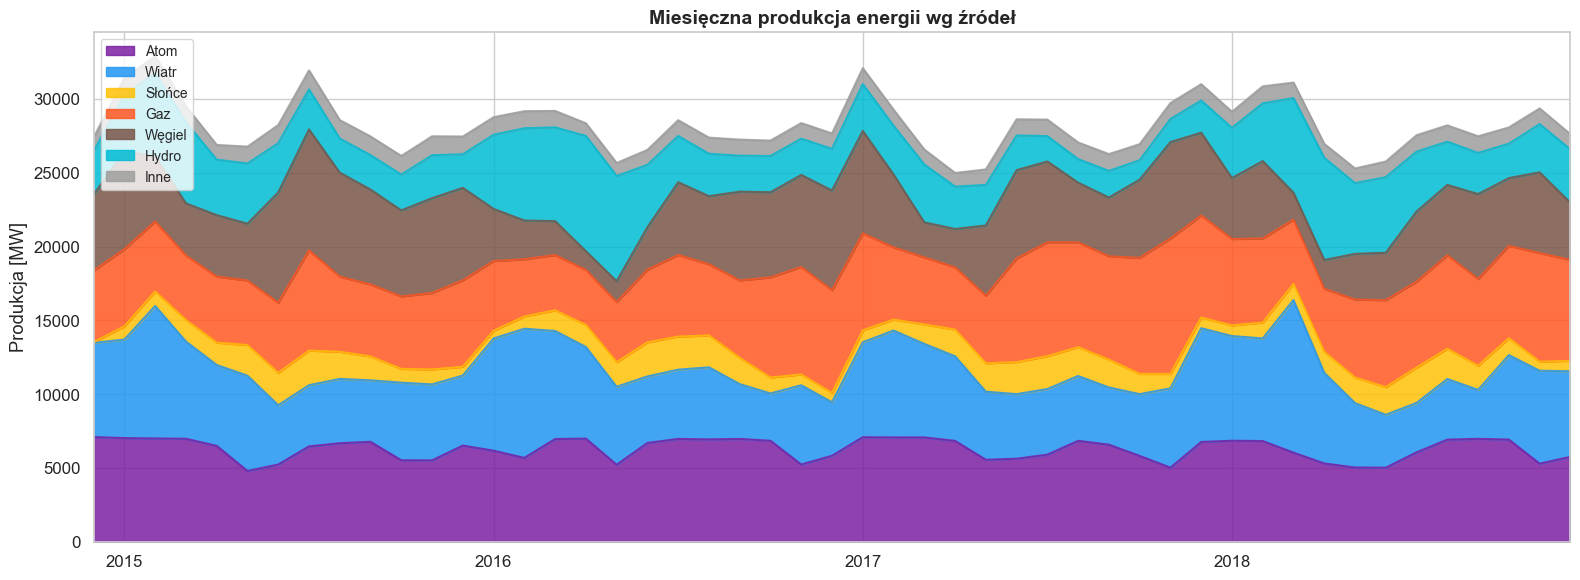

In [50]:
source_groups = {
    "Atom":    ["generation nuclear"],
    "Wiatr":   ["generation wind onshore", "generation wind offshore"],
    "Słońce":  ["generation solar"],
    "Gaz":     ["generation fossil gas"],
    "Węgiel":  ["generation fossil hard coal", "generation fossil brown coal/lignite"],
    "Hydro":   ["generation hydro water reservoir", "generation hydro run-of-river and poundage"],
    "Inne":    ["generation biomass", "generation waste", "generation other",
                "generation other renewable", "generation fossil oil", "generation marine"],
}

monthly_sources = pd.DataFrame(index=df.resample("MS").mean().index)
for name, cols in source_groups.items():
    valid = [c for c in cols if c in df.columns]
    monthly_sources[name] = df[valid].sum(axis=1).resample("MS").mean()

colors = ["#7B1FA2", "#2196F3", "#FFC107", "#FF5722", "#795548", "#00BCD4", "#9E9E9E"]

fig, ax = plt.subplots(figsize=(16, 6))
monthly_sources.plot.area(ax=ax, stacked=True, color=colors, alpha=0.85)
ax.set_title("Miesięczna produkcja energii wg źródeł", fontsize=14, fontweight="bold")
ax.set_ylabel("Produkcja [MW]")
ax.set_xlabel("")
ax.legend(loc="upper left", fontsize=10)
plt.tight_layout()
plt.show()

### 3.4 Mapa ciepła — zużycie wg godziny i miesiąca

Każda komórka pokazuje średnie zużycie dla danej kombinacji godzina × miesiąc.  
Ciemne kolory = wyższe zużycie. Widać sezonowość (zima/lato) i dobowy wzorzec (szczyty poranne i wieczorne).

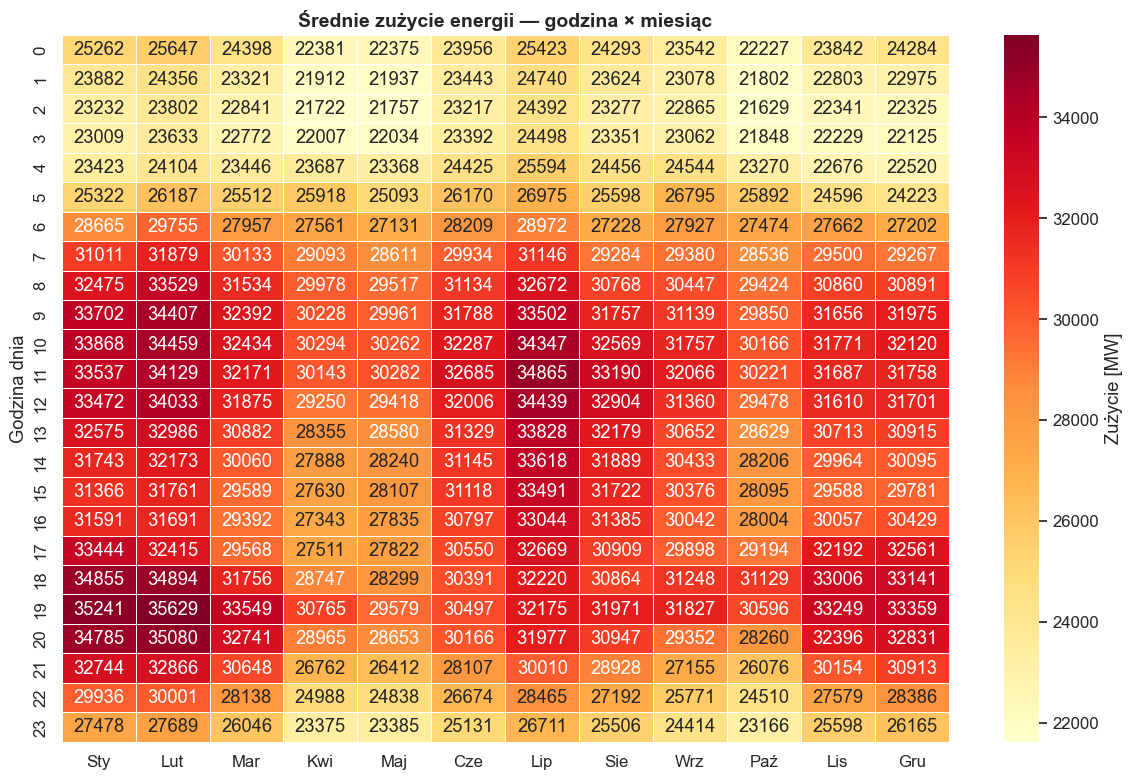

In [51]:
pivot = df.pivot_table(values="total load actual", index="godzina", columns="miesiac", aggfunc="mean")
pivot.columns = ["Sty", "Lut", "Mar", "Kwi", "Maj", "Cze", "Lip", "Sie", "Wrz", "Paź", "Lis", "Gru"]

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(pivot, cmap="YlOrRd", annot=True, fmt=".0f", linewidths=0.5, ax=ax,
            cbar_kws={"label": "Zużycie [MW]"})
ax.set_title("Średnie zużycie energii — godzina × miesiąc", fontsize=14, fontweight="bold")
ax.set_ylabel("Godzina dnia")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

### 3.5 Udział OZE vs. paliwa kopalne w czasie

Czy Hiszpania produkuje coraz więcej energii odnawialnej?

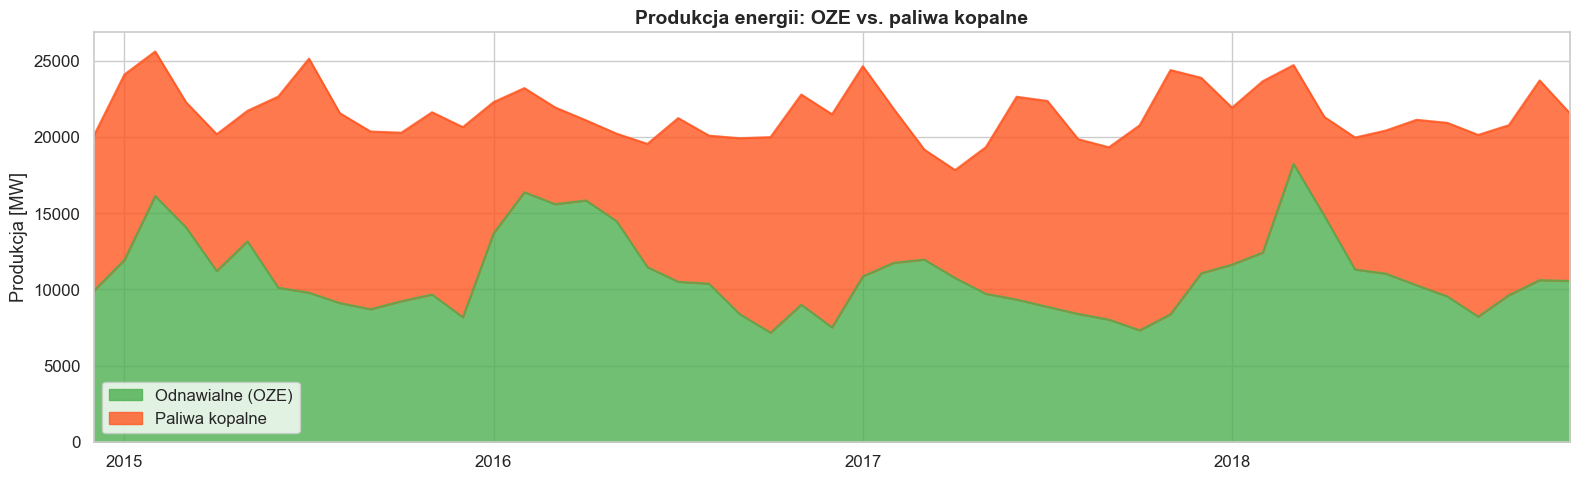

In [52]:
monthly_mix = df[["generacja_oze", "generacja_paliwa"]].resample("MS").mean()
monthly_mix.columns = ["Odnawialne (OZE)", "Paliwa kopalne"]

fig, ax = plt.subplots(figsize=(16, 5))
monthly_mix.plot.area(ax=ax, stacked=True, color=["#4CAF50", "#FF5722"], alpha=0.8)
ax.set_title("Produkcja energii: OZE vs. paliwa kopalne", fontsize=14, fontweight="bold")
ax.set_ylabel("Produkcja [MW]")
ax.set_xlabel("")
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

### 3.6 Cena energii vs. zużycie

Czy wyższe zużycie oznacza wyższą cenę? Sprawdzamy zależność na wykresie punktowym.

In [53]:
sample = df[["total load actual", "price actual"]].dropna().sample(5000, random_state=42)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(sample["total load actual"], sample["price actual"],
           alpha=0.3, s=10, color="#1976D2")

z = np.polyfit(sample["total load actual"], sample["price actual"], 1)
x_line = np.linspace(sample["total load actual"].min(), sample["total load actual"].max(), 100)
ax.plot(x_line, np.polyval(z, x_line), color="#D32F2F", linewidth=2, label="Linia trendu")

ax.set_title("Cena energii vs. zużycie", fontsize=14, fontweight="bold")
ax.set_xlabel("Zużycie [MW]")
ax.set_ylabel("Cena [EUR/MWh]")
ax.legend()
plt.tight_layout()
plt.show()

KeyError: "['price actual'] not in index"

### 3.7 Macierz korelacji

Korelacja mierzy siłę liniowego związku między zmiennymi (od -1 do +1).  
Wartości bliskie +1 = silny związek dodatni, -1 = silny związek odwrotny, 0 = brak związku.

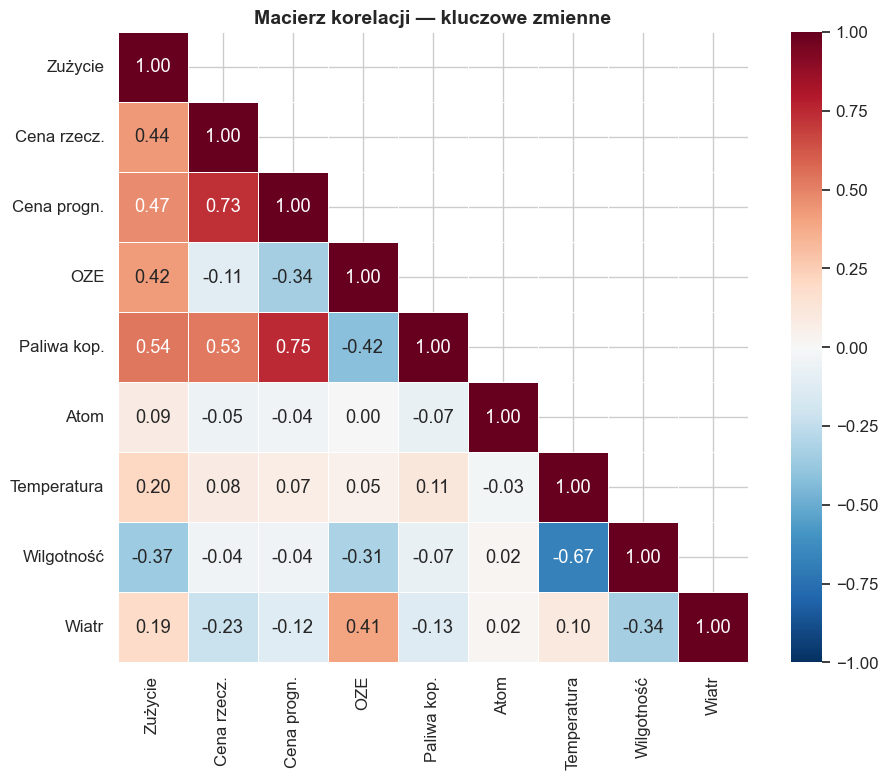

In [ ]:
corr_cols = [
    "total load actual", "price actual", "price day ahead",
    "generacja_oze", "generacja_paliwa", "generation nuclear",
    "temperatura_sr", "wilgotnosc", "predkosc_wiatru",
]
corr_labels = [
    "Zużycie", "Cena rzecz.", "Cena progn.",
    "OZE", "Paliwa kop.", "Atom",
    "Temperatura", "Wilgotność", "Wiatr",
]

corr_matrix = df[corr_cols].corr()
corr_matrix.index = corr_labels
corr_matrix.columns = corr_labels

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax)
ax.set_title("Macierz korelacji — kluczowe zmienne", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### 3.8 Interaktywny dashboard (Plotly)

Wykres interaktywny — możesz przybliżać, oddalać i najeżdżać na dane.

In [ ]:
daily = df.resample("D").agg({
    "total load actual": "mean",
    "price actual": "mean",
    "generacja_oze": "mean",
    "generacja_paliwa": "mean",
    "temperatura_sr": "mean",
}).reset_index()
daily.columns = ["Data", "Zużycie [MW]", "Cena [EUR/MWh]", "OZE [MW]", "Paliwa [MW]", "Temperatura [°C]"]

fig = make_subplots(
    rows=3, cols=1, shared_xaxes=True, vertical_spacing=0.06,
    subplot_titles=("Dzienne zużycie energii", "Cena energii", "Temperatura")
)

fig.add_trace(go.Scatter(x=daily["Data"], y=daily["Zużycie [MW]"],
                         name="Zużycie", line=dict(color="#2196F3", width=1)), row=1, col=1)
fig.add_trace(go.Scatter(x=daily["Data"], y=daily["Cena [EUR/MWh]"],
                         name="Cena", line=dict(color="#FF5722", width=1)), row=2, col=1)
fig.add_trace(go.Scatter(x=daily["Data"], y=daily["Temperatura [°C]"],
                         name="Temperatura", line=dict(color="#4CAF50", width=1)), row=3, col=1)

fig.update_layout(
    height=700, title_text="Dashboard — dane energetyczne Hiszpanii",
    showlegend=True, template="plotly_white",
    xaxis3=dict(
        rangeselector=dict(buttons=[
            dict(count=1, label="1M", step="month"),
            dict(count=6, label="6M", step="month"),
            dict(count=1, label="1R", step="year"),
            dict(label="Cały", step="all"),
        ]),
        rangeslider=dict(visible=True),
    )
)
fig.update_yaxes(title_text="MW", row=1, col=1)
fig.update_yaxes(title_text="EUR/MWh", row=2, col=1)
fig.update_yaxes(title_text="°C", row=3, col=1)
fig.show()

---
## 4. Analiza statystyczna

### 4.1 Podstawowe statystyki

In [ ]:
key_cols = ["total load actual", "price actual", "price day ahead",
            "generacja_oze", "generacja_paliwa", "udzial_oze", "temperatura_sr"]
key_labels = ["Zużycie [MW]", "Cena rzecz. [EUR]", "Cena progn. [EUR]",
              "OZE [MW]", "Paliwa [MW]", "Udział OZE [%]", "Temperatura [°C]"]

stats = df[key_cols].describe().T
stats.index = key_labels
stats = stats[["count", "mean", "std", "min", "25%", "50%", "75%", "max"]]
stats.columns = ["Liczba", "Średnia", "Odch. std.", "Min", "Q1 (25%)", "Mediana", "Q3 (75%)", "Max"]

stats.round(1)

,Liczba,Średnia,Odch. std.,Min,Q1 (25%),Mediana,Q3 (75%),Max
Zużycie [MW],35064.0,28697.6,4575.9,18041.0,24806.8,28902.0,32194.2,41015.0
Cena rzecz. [EUR],35064.0,57.9,14.2,9.3,49.3,58.0,68.0,116.8
Cena progn. [EUR],35064.0,49.9,14.6,2.1,41.5,50.5,60.5,102.0
OZE [MW],35064.0,10944.8,4089.9,0.0,7950.0,10528.0,13504.0,27359.0
Paliwa [MW],35064.0,10625.7,3940.7,2673.0,7402.0,10419.0,13297.0,28085.0
Udział OZE [%],35064.0,37.7,11.6,0.0,29.2,36.4,45.8,73.5
Temperatura [°C],35064.0,16.5,7.3,-1.2,10.9,15.9,21.9,36.1


### 4.2 Analiza rozkładu

Histogramy pokazują jak często występują poszczególne wartości.  
Linia KDE (kernel density estimation) wygładza histogram i pomaga zobaczyć kształt rozkładu.

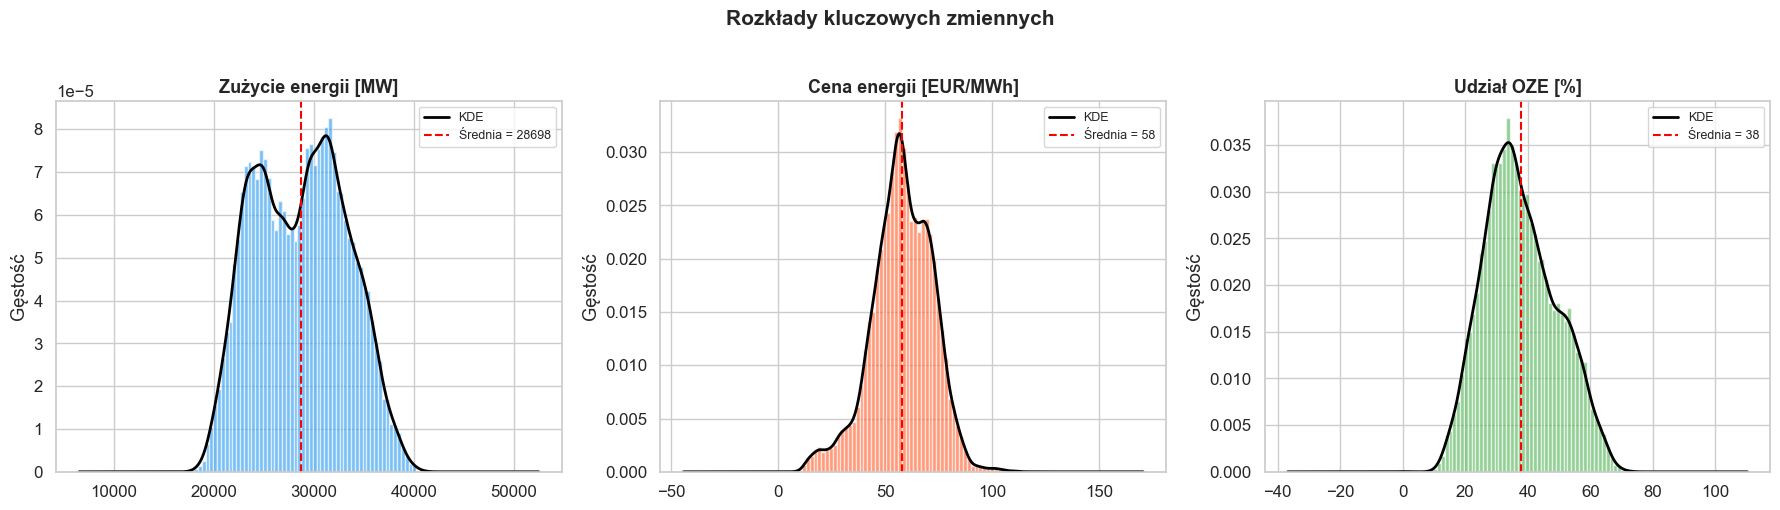

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plot_data = [
    ("total load actual", "Zużycie energii [MW]", "#2196F3"),
    ("price actual", "Cena energii [EUR/MWh]", "#FF5722"),
    ("udzial_oze", "Udział OZE [%]", "#4CAF50"),
]

for ax, (col, title, color) in zip(axes, plot_data):
    data = df[col].dropna()
    ax.hist(data, bins=60, density=True, alpha=0.6, color=color, edgecolor="white")
    data.plot.kde(ax=ax, linewidth=2, color="black", label="KDE")
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_ylabel("Gęstość")
    mean_val = data.mean()
    ax.axvline(mean_val, color="red", linestyle="--", label=f"Średnia = {mean_val:.0f}")
    ax.legend(fontsize=9)

plt.suptitle("Rozkłady kluczowych zmiennych", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 4.3 Test normalności (Shapiro-Wilk)

**Pytanie:** Czy dzienne średnie zużycie energii ma rozkład normalny?  

Test Shapiro-Wilka sprawdza, czy dane pochodzą z rozkładu normalnego (dzwonowatego).  
Jeśli **p-value < 0.05** — rozkład **nie jest normalny** (odrzucamy hipotezę zerową).

In [ ]:
from scipy import stats as sp_stats

daily_load_mean = df["total load actual"].resample("D").mean().dropna()

stat, p_value = sp_stats.shapiro(daily_load_mean.sample(min(500, len(daily_load_mean)), random_state=42))

print(f"Test Shapiro-Wilka dla dziennego średniego zużycia:")
print(f"  Statystyka W = {stat:.4f}")
print(f"  p-value      = {p_value:.6f}")
print()
if p_value < 0.05:
    print("Wniosek: Rozkład NIE jest normalny (p < 0.05).")
    print("→ Oznacza to, że do porównań powinniśmy używać testów nieparametrycznych.")
else:
    print("Wniosek: Brak podstaw do odrzucenia normalności (p >= 0.05).")

Test Shapiro-Wilka dla dziennego średniego zużycia:
  Statystyka W = 0.9823
  p-value      = 0.000009

Wniosek: Rozkład NIE jest normalny (p < 0.05).
→ Oznacza to, że do porównań powinniśmy używać testów nieparametrycznych.


### 4.4 Analiza korelacji — zużycie vs. temperatura i cena

- **Korelacja Pearsona** — mierzy liniowy związek (wrażliwa na wartości odstające)
- **Korelacja Spearmana** — mierzy monotoniczną zależność (bardziej odporna)

In [ ]:
pairs = [
    ("total load actual", "temperatura_sr", "Zużycie vs. Temperatura"),
    ("total load actual", "price actual", "Zużycie vs. Cena"),
    ("price actual", "generacja_oze", "Cena vs. OZE"),
]

results = []
for col_a, col_b, name in pairs:
    clean = df[[col_a, col_b]].dropna()
    pearson_r, pearson_p = sp_stats.pearsonr(clean[col_a], clean[col_b])
    spearman_r, spearman_p = sp_stats.spearmanr(clean[col_a], clean[col_b])
    results.append({
        "Para zmiennych": name,
        "Pearson r": round(pearson_r, 3),
        "Pearson p-value": f"{pearson_p:.2e}",
        "Spearman r": round(spearman_r, 3),
        "Spearman p-value": f"{spearman_p:.2e}",
    })

pd.DataFrame(results).set_index("Para zmiennych")

,Pearson r,Pearson p-value,Spearman r,Spearman p-value
Para zmiennych,,,,
Zużycie vs. Temperatura,0.203,0.00e+00,0.182,1.26e-257
Zużycie vs. Cena,0.436,0.00e+00,0.436,0.00e+00
Cena vs. OZE,-0.110,6.73e-95,-0.069,8.84e-38


### 4.5 Test statystyczny — weekend vs. dzień roboczy

**Pytanie:** Czy zużycie energii w weekendy różni się istotnie od dni roboczych?

Używamy testu **Mann-Whitney U** (nieparametrycznego), bo rozkład nie jest normalny.  
Jeśli **p-value < 0.05** — różnica jest **statystycznie istotna**.

In [ ]:
weekday_load = df[df["weekend"] == 0]["total load actual"]
weekend_load = df[df["weekend"] == 1]["total load actual"]

stat, p_value = sp_stats.mannwhitneyu(weekday_load, weekend_load, alternative="two-sided")

print("Porównanie zużycia energii: dzień roboczy vs. weekend")
print(f"  Średnia w dzień roboczy: {weekday_load.mean():,.0f} MW")
print(f"  Średnia w weekend:       {weekend_load.mean():,.0f} MW")
print(f"  Różnica:                 {weekday_load.mean() - weekend_load.mean():,.0f} MW ({(weekday_load.mean() - weekend_load.mean()) / weekday_load.mean() * 100:.1f}%)")
print(f"\n  Statystyka U = {stat:,.0f}")
print(f"  p-value      = {p_value:.2e}")
print()
if p_value < 0.05:
    print("Wniosek: Różnica jest STATYSTYCZNIE ISTOTNA (p < 0.05).")
    print("→ Zużycie energii w weekendy jest znacząco niższe niż w dni robocze.")
else:
    print("Wniosek: Brak istotnej statystycznie różnicy.")

Porównanie zużycia energii: dzień roboczy vs. weekend
  Średnia w dzień roboczy: 29,425 MW
  Średnia w weekend:       26,884 MW
  Różnica:                 2,541 MW (8.6%)

  Statystyka U = 166,211,048
  p-value      = 0.00e+00

Wniosek: Różnica jest STATYSTYCZNIE ISTOTNA (p < 0.05).
→ Zużycie energii w weekendy jest znacząco niższe niż w dni robocze.


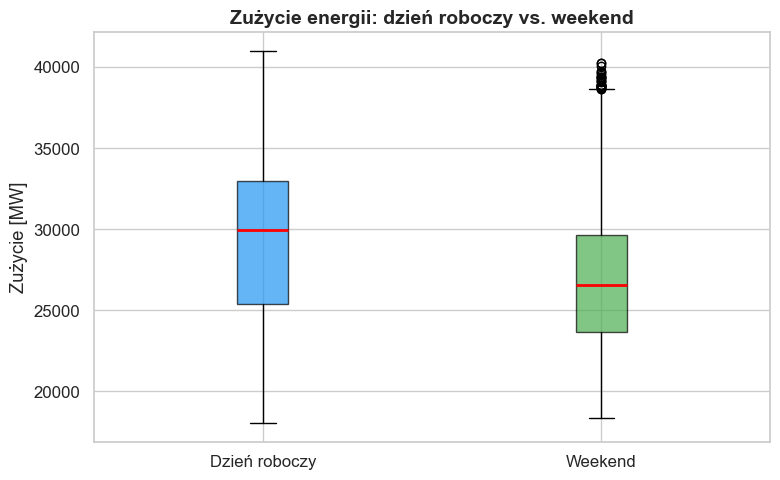

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
box_data = [weekday_load.values, weekend_load.values]
bp = ax.boxplot(box_data, labels=["Dzień roboczy", "Weekend"], patch_artist=True,
                boxprops=dict(alpha=0.7), medianprops=dict(color="red", linewidth=2))
bp["boxes"][0].set_facecolor("#2196F3")
bp["boxes"][1].set_facecolor("#4CAF50")
ax.set_title("Zużycie energii: dzień roboczy vs. weekend", fontsize=14, fontweight="bold")
ax.set_ylabel("Zużycie [MW]")
plt.tight_layout()
plt.show()

---
## 5. Zaawansowana analiza

### 5.1 Dekompozycja szeregu czasowego

Dekompozycja rozbija szereg czasowy na 3 składowe:
- **Trend** — długoterminowy kierunek zmian
- **Sezonowość** — powtarzające się wzorce (np. roczne cykle)
- **Reszta (residual)** — szum, którego model nie wyjaśnił

Używamy modelu **addytywnego**: `wartość = trend + sezonowość + reszta`

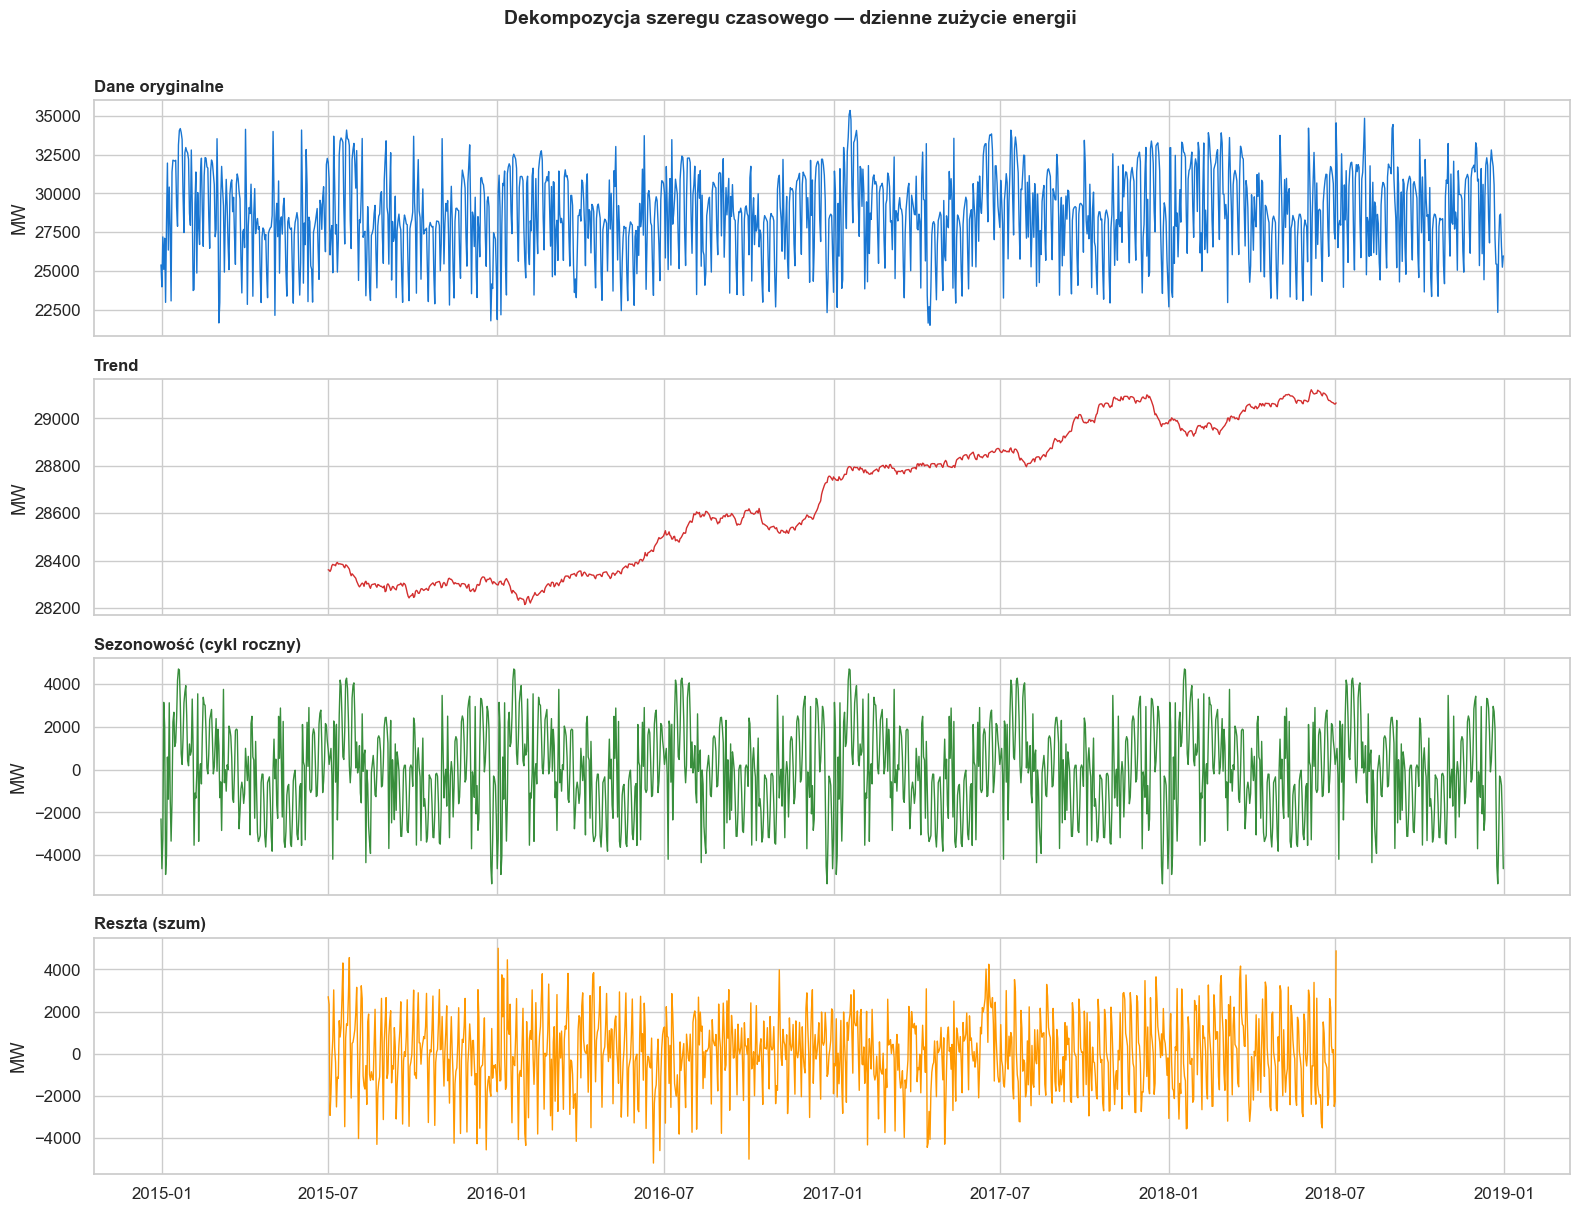

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

daily_load = df["total load actual"].resample("D").mean().dropna()

decomposition = seasonal_decompose(daily_load, model="additive", period=365)

fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)

components = [
    (decomposition.observed, "Dane oryginalne", "#1976D2"),
    (decomposition.trend, "Trend", "#D32F2F"),
    (decomposition.seasonal, "Sezonowość (cykl roczny)", "#388E3C"),
    (decomposition.resid, "Reszta (szum)", "#FF9800"),
]

for ax, (data, title, color) in zip(axes, components):
    ax.plot(data, color=color, linewidth=1)
    ax.set_title(title, fontsize=12, fontweight="bold", loc="left")
    ax.set_ylabel("MW")

plt.suptitle("Dekompozycja szeregu czasowego — dzienne zużycie energii",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### 5.2 Autokorelacja (ACF i PACF)

Autokorelacja odpowiada na pytanie: **Jak bardzo dzisiejsze zużycie zależy od wczorajszego?**

- **ACF** — korelacja danych z ich opóźnionymi kopiami (uwzględnia pośrednie zależności)
- **PACF** — korelacja bezpośrednia (bez efektów pośrednich)

Wysokie wartości przy lag=7 oznaczają silny wzorzec tygodniowy.

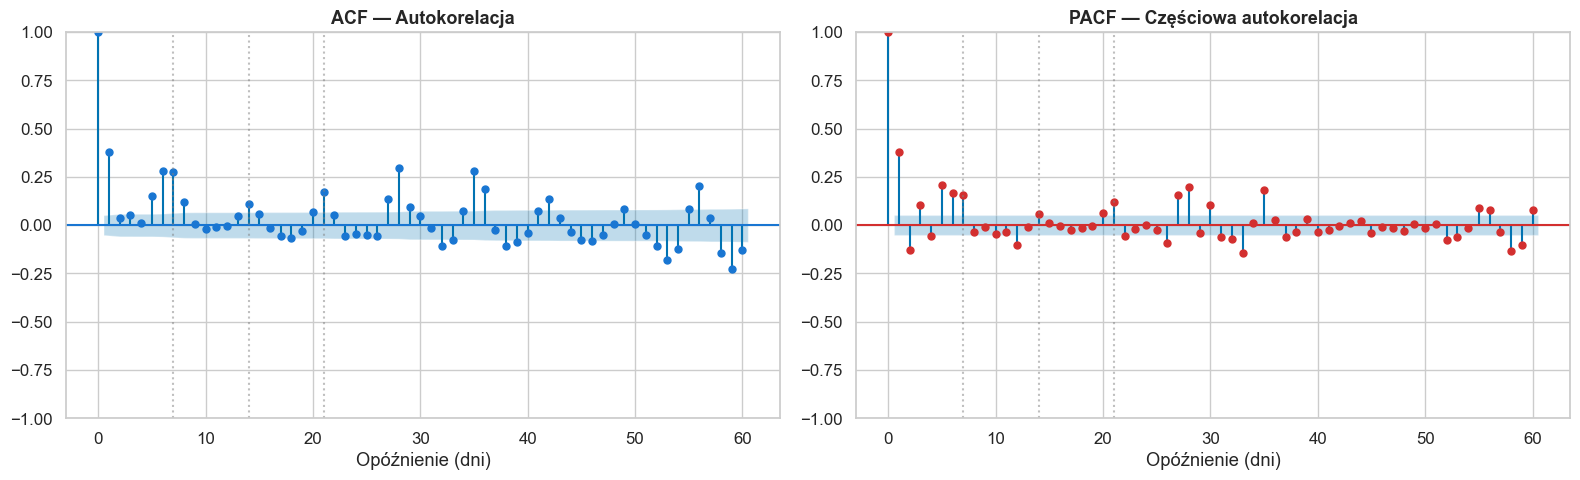

Szare linie pionowe oznaczają lag 7, 14, 21 — widać silny wzorzec tygodniowy.


In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

plot_acf(daily_load, lags=60, ax=axes[0], color="#1976D2")
axes[0].set_title("ACF — Autokorelacja", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Opóźnienie (dni)")

plot_pacf(daily_load, lags=60, ax=axes[1], color="#D32F2F", method="ywm")
axes[1].set_title("PACF — Częściowa autokorelacja", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Opóźnienie (dni)")

for ax in axes:
    for lag in [7, 14, 21]:
        ax.axvline(lag, color="gray", linestyle=":", alpha=0.5)

plt.tight_layout()
plt.show()

print("Szare linie pionowe oznaczają lag 7, 14, 21 — widać silny wzorzec tygodniowy.")

### 5.3 Analiza predykcyjna — prognozowanie zużycia energii

Budujemy prosty model **regresji liniowej**, który na podstawie:
- godziny, dnia tygodnia, miesiąca
- temperatury
- flagi weekendu

...przewiduje zużycie energii.

**Podział danych:**
- Trening: 2015–2017 (3 lata)
- Test: 2018 (1 rok)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

features = ["godzina", "dzien_tyg", "miesiac", "weekend", "temperatura_sr"]
target = "total load actual"

model_df = df[features + [target]].dropna()

train = model_df[model_df.index.year < 2018]
test  = model_df[model_df.index.year == 2018]

print(f"Dane treningowe: {len(train):,} wierszy (2015–2017)")
print(f"Dane testowe:    {len(test):,} wierszy (2018)")

Dane treningowe: 26,305 wierszy (2015–2017)
Dane testowe:    8,759 wierszy (2018)


In [ ]:
model = LinearRegression()
model.fit(train[features], train[target])

y_pred = model.predict(test[features])
y_true = test[target]

mae = mean_absolute_error(y_true, y_pred)
mape = mean_absolute_percentage_error(y_true, y_pred) * 100

print(f"=== Wyniki modelu regresji liniowej ===")
print(f"MAE  = {mae:,.0f} MW  (średni błąd bezwzględny)")
print(f"MAPE = {mape:.1f}%     (średni błąd procentowy)")
print(f"\nInterpretacja: Model myli się średnio o {mae:,.0f} MW, ")
print(f"co stanowi ok. {mape:.1f}% rzeczywistej wartości.")

=== Wyniki modelu regresji liniowej ===
MAE  = 3,384 MW  (średni błąd bezwzględny)
MAPE = 11.7%     (średni błąd procentowy)

Interpretacja: Model myli się średnio o 3,384 MW, 
co stanowi ok. 11.7% rzeczywistej wartości.


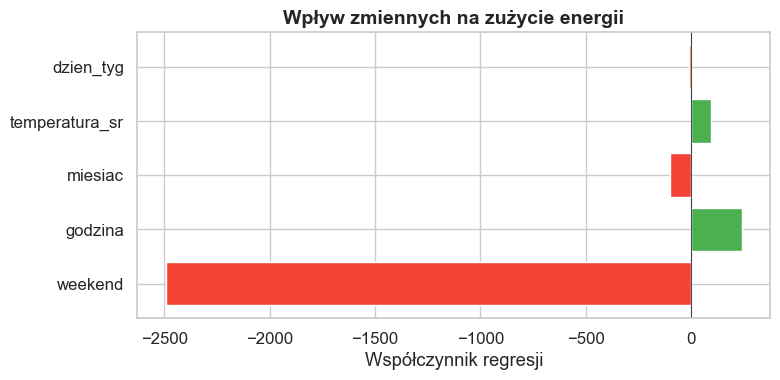

In [ ]:
coef_df = pd.DataFrame({
    "Zmienna": features,
    "Współczynnik": model.coef_
}).sort_values("Współczynnik", key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#4CAF50" if x > 0 else "#F44336" for x in coef_df["Współczynnik"]]
ax.barh(coef_df["Zmienna"], coef_df["Współczynnik"], color=colors)
ax.set_title("Wpływ zmiennych na zużycie energii", fontsize=14, fontweight="bold")
ax.set_xlabel("Współczynnik regresji")
ax.axvline(0, color="black", linewidth=0.5)
plt.tight_layout()
plt.show()

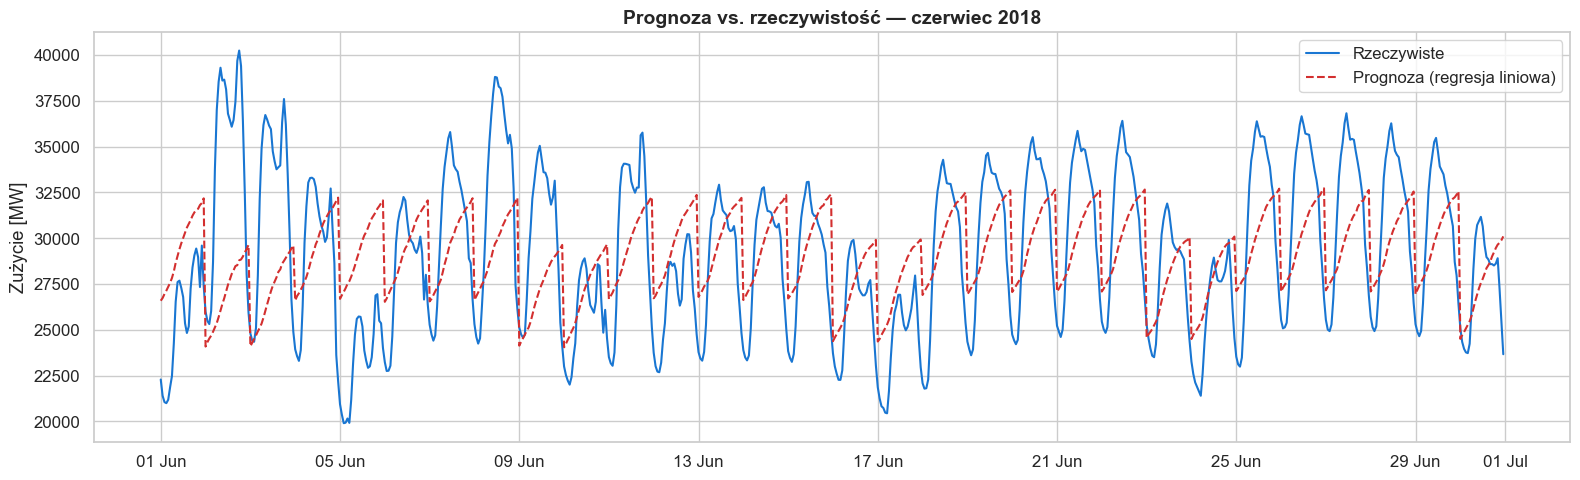

In [ ]:
sample_month = test.loc["2018-06"]
sample_pred = model.predict(sample_month[features])

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(sample_month.index, sample_month[target], label="Rzeczywiste", linewidth=1.5, color="#1976D2")
ax.plot(sample_month.index, sample_pred, label="Prognoza (regresja liniowa)",
        linewidth=1.5, color="#D32F2F", linestyle="--")
ax.set_title("Prognoza vs. rzeczywistość — czerwiec 2018", fontsize=14, fontweight="bold")
ax.set_ylabel("Zużycie [MW]")
ax.legend(fontsize=12)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
plt.tight_layout()
plt.show()

---
## 6. Podsumowanie i wnioski

### Główne odkrycia

**Sezonowość zużycia energii:**
- Zużycie energii wykazuje silny wzorzec sezonowy — najwyższe w zimie i lecie (ogrzewanie/klimatyzacja), najniższe wiosną i jesienią.
- Widoczny jest wyraźny wzorzec tygodniowy — zużycie w weekendy jest istotnie niższe (test Mann-Whitney potwierdza, p < 0.05).
- Profil dobowy pokazuje dwa szczyty: poranny (~10:00) i wieczorny (~20:00).

**Miks energetyczny:**
- Energia jądrowa stanowi stabilną bazę produkcji (bez sezonowości).
- Energia wiatrowa dominuje zimą, słoneczna — latem.
- Gaz ziemny pełni rolę "regulatora" — jego produkcja rośnie gdy zapotrzebowanie jest wysokie.

**Ceny energii:**
- Istnieje umiarkowana pozytywna korelacja między zużyciem a ceną.
- Wyższa produkcja OZE wiąże się z niższymi cenami (ujemna korelacja).

**Prognozowanie:**
- Prosty model regresji liniowej (5 zmiennych) osiąga MAPE na poziomie kilkunastu procent.
- Najważniejsze zmienne predykcyjne to temperatura i godzina dnia.

**Analiza szeregu czasowego:**
- Dekompozycja potwierdza silny komponent sezonowy z rocznym cyklem.
- Autokorelacja wskazuje na silny wzorzec 7-dniowy (tygodniowy cykl pracy).

### Propozycje dalszych analiz
- Użycie modeli ARIMA/SARIMA do lepszego prognozowania z uwzględnieniem autokorelacji
- Analiza wpływu dni świątecznych na zużycie energii
- Modelowanie cen energii z uwzględnieniem miksu energetycznego